In [1]:
import random
import numpy as np
from PIL import Image
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler, SubsetRandomSampler
from torchvision.transforms import Compose, ToTensor, Normalize, ToPILImage, RandomHorizontalFlip, Resize

!pip install torchsummary
from torchsummary import summary

import matplotlib.pyplot as plt
%matplotlib inline

# This line detects if we have a gpu support on our system
device = ("cuda" if torch.cuda.is_available() else "cpu")
print (device)

/home/tiva/anaconda3/envs/MonaiLatestEnv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


### Define the Loss function

In [2]:
#multi-class classification
criterion_multi_class = torch.nn.CrossEntropyLoss()


### Define your train val test dataset

In [18]:
from torchvision import datasets, transforms
from torch.utils.data.sampler import  SubsetRandomSampler  #for validation test

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Normalize the val set same as training set without augmentation
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])                 
#Load the data: train and test sets
trainset = datasets.CIFAR10('~/CF_data', download=True, train=True, transform=transform_train)
validset = datasets.CIFAR10('~/CF_data', download=False, train=True, transform=transform_val)
testset = datasets.CIFAR10('~/CF_data', download=True, train=False, transform=transform_val)

#Preparing the validation test
indices = list(range(len(trainset)))
np.random.shuffle(indices)
#to get 20% of the train set
split = int(np.floor(0.2 * len(trainset)))
print(len(indices[split:]))
train_sample = SubsetRandomSampler(indices[split:])
valid_sample = SubsetRandomSampler(indices[:split])

#Data Loader
trainloader = torch.utils.data.DataLoader(trainset, sampler=train_sample, batch_size=64)
validloader = torch.utils.data.DataLoader(validset, sampler=valid_sample, batch_size=64)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)


######################

class_names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']




Files already downloaded and verified
Files already downloaded and verified
40000


In [4]:
 #  defining accuracy function
def accuracy(network, dataloader):
      network.eval()
      total_correct = 0
      total_instances = 0
      for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)
        predictions = torch.argmax(network(images), dim=1)
        correct_predictions = sum(predictions==labels).item()
        total_correct+=correct_predictions
        total_instances+=len(images)
      return round(total_correct/total_instances, 3)

### Simple convolutional neural network

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layer = nn.Sequential(
            # Conv Layer block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Conv Layer block 2
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Conv Layer block 3
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        # conv layers
        x = self.conv_layer(x)
        # flatten
        x = x.view(x.size(0), -1)
        # fc layer
        x = self.fc_layer(x)
        return x

cnn_model= SimpleCNN()
cnn_model.to(device)
summary(cnn_model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
              ReLU-2           [-1, 32, 32, 32]               0
            Conv2d-3           [-1, 64, 32, 32]          18,496
              ReLU-4           [-1, 64, 32, 32]               0
         MaxPool2d-5           [-1, 64, 16, 16]               0
            Conv2d-6          [-1, 128, 16, 16]          73,856
              ReLU-7          [-1, 128, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]         147,584
              ReLU-9          [-1, 128, 16, 16]               0
        MaxPool2d-10            [-1, 128, 8, 8]               0
           Conv2d-11            [-1, 256, 8, 8]         295,168
             ReLU-12            [-1, 256, 8, 8]               0
           Conv2d-13            [-1, 256, 8, 8]         590,080
             ReLU-14            [-1, 25

In [14]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if not title:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

#     print(cm)

    fig, ax = plt.subplots(figsize=(7,7))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")
    # Loop over data dimensions and create text annotations.
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

## Task 1: 
* Experiment with different Optimizers and learning rate schedulers
* Plot the learning curves and analyze your results

SimpleCNN(
  (conv_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Linear(in_features=4096, out_features=102

  0%|          | 0/625 [00:00<?, ?it/s]

100%|██████████| 625/625 [00:11<00:00, 54.90it/s]


deriving training accuracy...


100%|██████████| 625/625 [00:09<00:00, 63.18it/s]


validating...


100%|██████████| 157/157 [00:01<00:00, 95.42it/s]


deriving validation accuracy...


100%|██████████| 157/157 [00:01<00:00, 94.72it/s]


Confusion matrix, without normalization


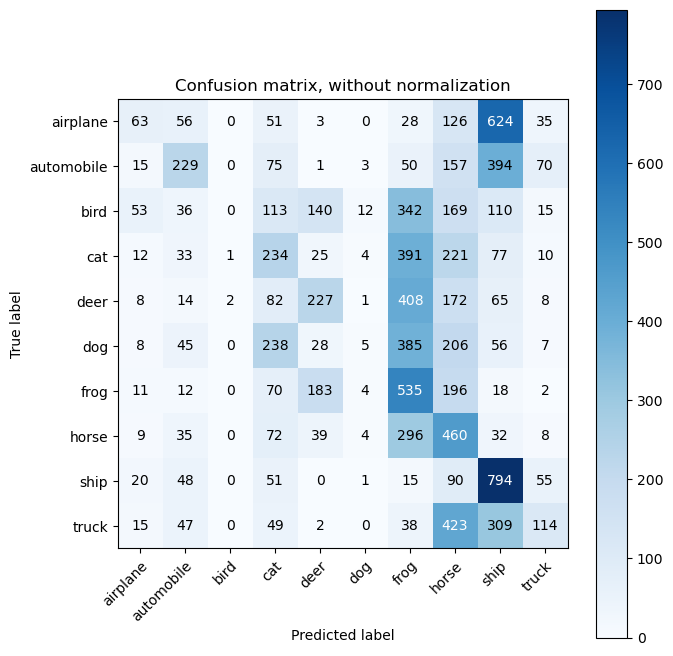

training_loss: 2.1783  training_accuracy: 0.26  validation_loss: 1.9124 validation_accuracy: 0.266

Epoch 2/10
training...


100%|██████████| 625/625 [00:10<00:00, 57.07it/s]


deriving training accuracy...


100%|██████████| 625/625 [00:10<00:00, 60.10it/s]


validating...


100%|██████████| 157/157 [00:01<00:00, 93.74it/s]


deriving validation accuracy...


100%|██████████| 157/157 [00:01<00:00, 93.64it/s]


Confusion matrix, without normalization


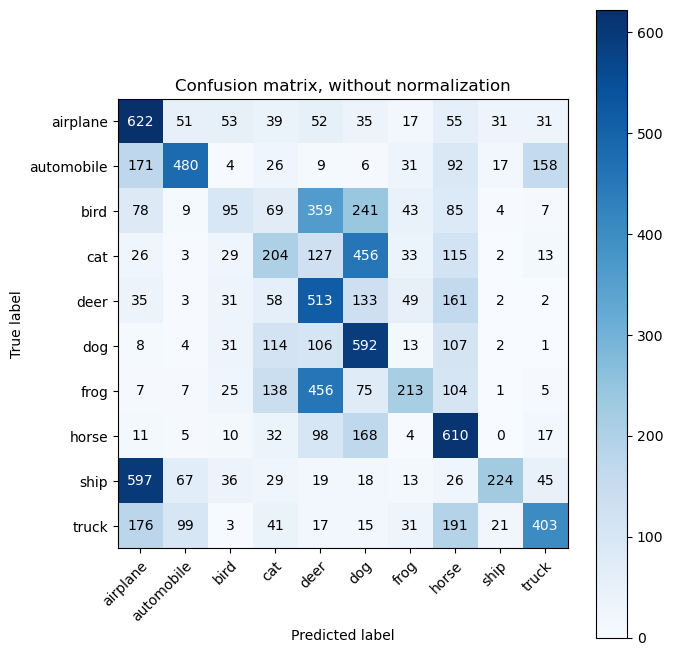

training_loss: 1.7619  training_accuracy: 0.393  validation_loss: 1.5678 validation_accuracy: 0.396

Epoch 3/10
training...


100%|██████████| 625/625 [00:11<00:00, 56.00it/s]


deriving training accuracy...


100%|██████████| 625/625 [00:10<00:00, 60.74it/s]


validating...


100%|██████████| 157/157 [00:01<00:00, 92.99it/s]


deriving validation accuracy...


100%|██████████| 157/157 [00:01<00:00, 93.07it/s]


Confusion matrix, without normalization


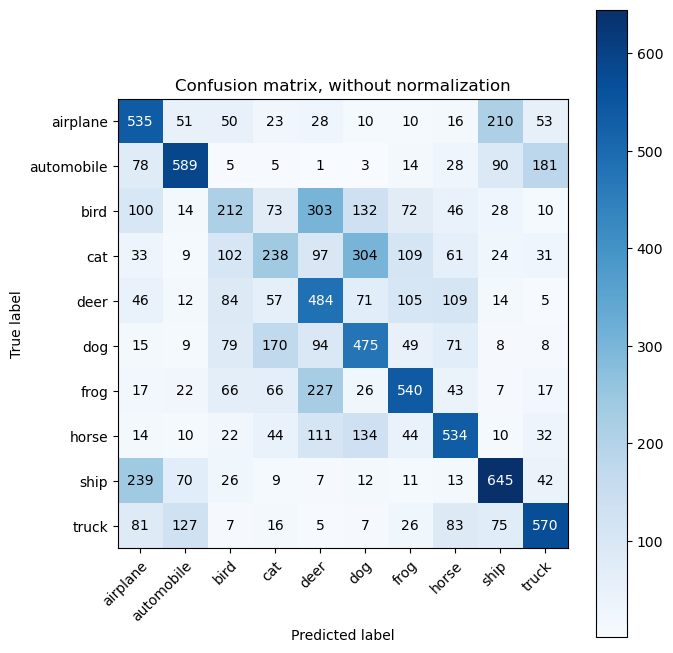

training_loss: 1.4731  training_accuracy: 0.467  validation_loss: 1.3817 validation_accuracy: 0.482

Epoch 4/10
training...


100%|██████████| 625/625 [00:10<00:00, 59.58it/s]


deriving training accuracy...


100%|██████████| 625/625 [00:09<00:00, 64.87it/s]


validating...


100%|██████████| 157/157 [00:01<00:00, 98.67it/s]


deriving validation accuracy...


100%|██████████| 157/157 [00:01<00:00, 97.24it/s]


Confusion matrix, without normalization


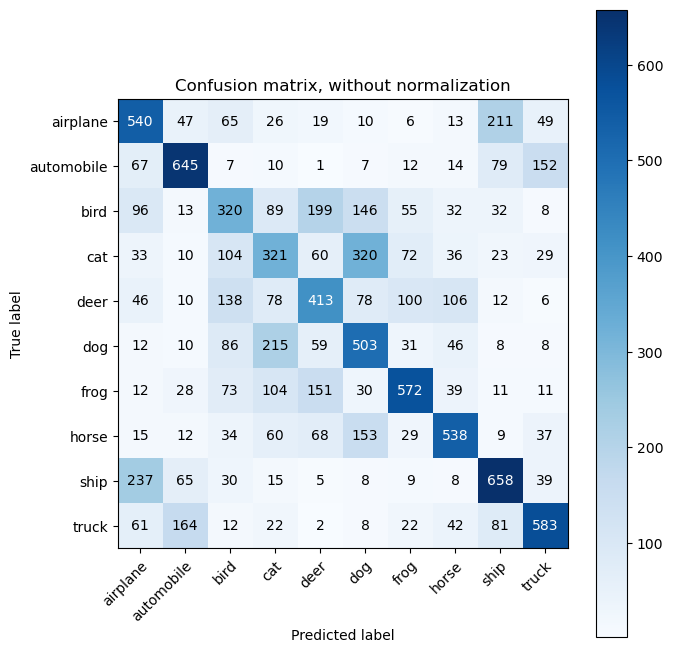

training_loss: 1.4145  training_accuracy: 0.489  validation_loss: 1.3159 validation_accuracy: 0.509

Epoch 5/10
training...


100%|██████████| 625/625 [00:10<00:00, 57.54it/s]


deriving training accuracy...


100%|██████████| 625/625 [00:09<00:00, 64.30it/s]


validating...


100%|██████████| 157/157 [00:01<00:00, 98.46it/s]


deriving validation accuracy...


100%|██████████| 157/157 [00:01<00:00, 97.12it/s]


Confusion matrix, without normalization


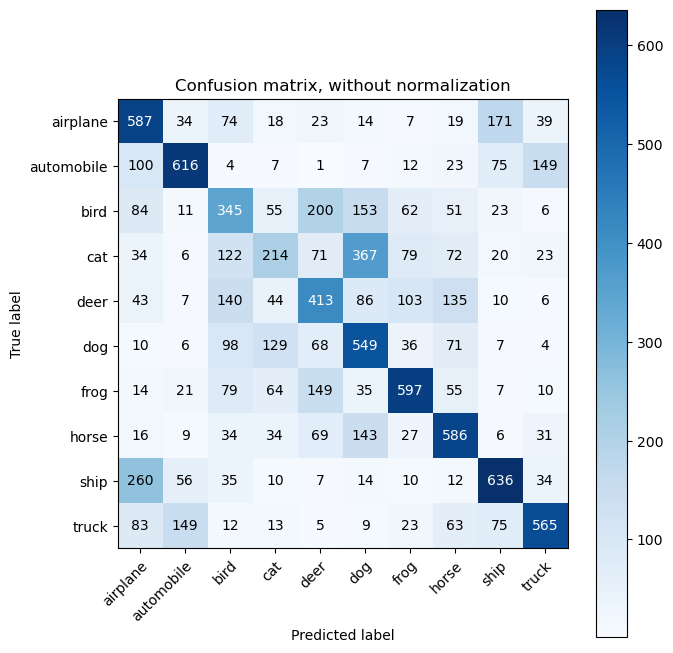

training_loss: 1.3634  training_accuracy: 0.498  validation_loss: 1.3125 validation_accuracy: 0.511

Epoch 6/10
training...


100%|██████████| 625/625 [00:10<00:00, 58.25it/s]


deriving training accuracy...


100%|██████████| 625/625 [00:10<00:00, 61.05it/s]


validating...


100%|██████████| 157/157 [00:01<00:00, 97.52it/s]


deriving validation accuracy...


100%|██████████| 157/157 [00:01<00:00, 96.19it/s]


Confusion matrix, without normalization


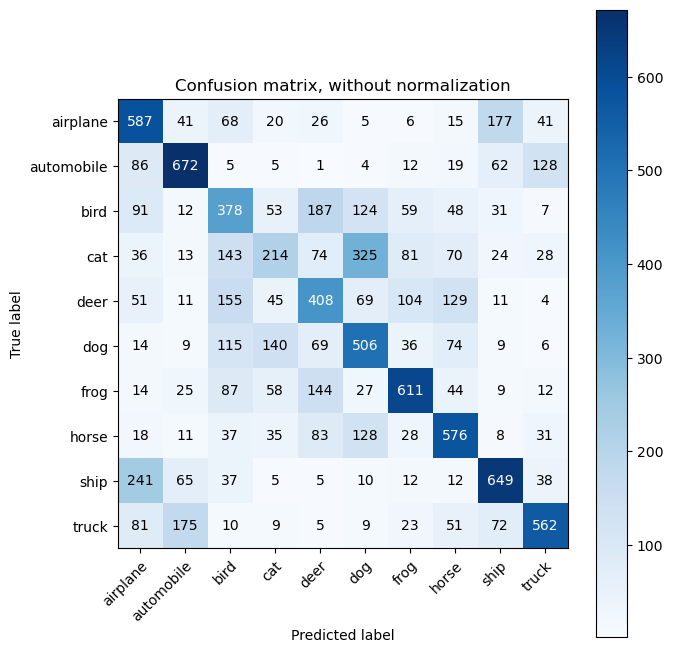

training_loss: 1.3546  training_accuracy: 0.502  validation_loss: 1.3012 validation_accuracy: 0.516

Epoch 7/10
training...


 84%|████████▍ | 527/625 [00:09<00:01, 58.41it/s]


KeyboardInterrupt: 

In [19]:
#!pip install tensorboard
from torch.autograd import Variable
from tqdm import tqdm
import os
from datetime import datetime

from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()
model = SimpleCNN()
model.to(device)
learning_rate = 0.01
#################################################################
# TODO: Insert your code below
# Experiment with different optimizers and learning rates
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
# define the scheduler
# 
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)
#################################################################
print(model)

start_epoch = 0
epochs = 10

####
#  creating log
log_dict = {
        'training_loss_per_batch': [],
        'validation_loss_per_batch': [],
        'training_accuracy_per_epoch': [],
        'validation_accuracy_per_epoch': []
    } 


#################################################################
# TODO: If you use the scheduler, you need to adjust the code below
for epoch in range(epochs):
      print(f'Epoch {epoch+1}/{epochs}')
      train_losses = []

      #  training
      print('training...')
      model.train()
      for images, labels in tqdm(trainloader):
        #  sending data to device
        images, labels = images.to(device), labels.to(device)
        #  resetting gradients
        optimizer.zero_grad()
        #  making predictions
        predictions = model(images)
        #  computing loss
        loss = criterion_multi_class(predictions, labels)
        log_dict['training_loss_per_batch'].append(loss.item())
        train_losses.append(loss.item())
        #  computing gradients
        loss.backward()
        #  updating weights
        optimizer.step()
      ##########################
      #  scheduler step  
      scheduler.step()
      ##########################
      with torch.no_grad():
        print('deriving training accuracy...')
        #  computing training accuracy
        train_accuracy = accuracy(model, trainloader)
        log_dict['training_accuracy_per_epoch'].append(train_accuracy)
        #  validation
        print('validating...')
        val_losses = []
        #  setting convnet to evaluation mode
        model.eval()
        ########################################
        predictions_val = []
        labels_val = []
        for images, labels in tqdm(validloader):
          labels_val.append(labels)
          #  sending data to device
          images, labels = images.to(device), labels.to(device)
          #  making predictions
          predictions = model(images)
          predictions_val.append(predictions)
          #  computing loss
          val_loss = criterion_multi_class(predictions, labels)
          log_dict['validation_loss_per_batch'].append(val_loss.item())
          val_losses.append(val_loss.item())
        #  computing accuracy
        print('deriving validation accuracy...')
        val_accuracy = accuracy(model, validloader)
        log_dict['validation_accuracy_per_epoch'].append(val_accuracy)
        predictions_val = torch.cat(predictions_val)
        labels_val = torch.cat(labels_val)  
         # confusion matrix
        plot_confusion_matrix(labels_val.cpu(), torch.argmax(predictions_val, dim=1).cpu(), classes=class_names,
                      title='Confusion matrix, without normalization')
        plt.show()

      train_losses = np.array(train_losses).mean()
      writer.add_scalar("Loss/train", train_losses, epoch)
      val_losses = np.array(val_losses).mean()

      print(f'training_loss: {round(train_losses, 4)}  training_accuracy: '+
      f'{train_accuracy}  validation_loss: {round(val_losses, 4)} '+  
      f'validation_accuracy: {val_accuracy}\n')

      
####
#  saving model
# Get the current datetime
current_datetime = datetime.now()

# Convert the datetime to a string
datetime_string = current_datetime.strftime("%Y-%m-%d_%H-%M-%S")

print(datetime_string)

torch.save(model.state_dict(), 'model_Shallow_FMNIST'+datetime_string+'.pth')
print('model saved')
writer.close()

## Task 2: Batch Normalization
* Add Batch Normalization layers to the network architecture
* Train the updated network, try to increase the learning rate
* Analyze the convergence and the final results

In [ ]:
#######################################
# TODO: Insert your code below
# Insert BatchNorm2d layers in the CNN model
###########################################
class SimpleCNNwBN(nn.Module):
    def __init__(self):
        super(SimpleCNNwBN, self).__init__()
        self.conv_layer = nn.Sequential(
            # Conv Layer block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Conv Layer block 2
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Conv Layer block 3
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        # conv layers
        x = self.conv_layer(x)
        # flatten
        x = x.view(x.size(0), -1)
        # fc layer
        x = self.fc_layer(x)
        return x

cnn_model1= SimpleCNNwBN()
cnn_model1.to(device)
summary(cnn_model1, (3, 32, 32))

## Task 3: Complexity of the model
* Simplify your model and observe the underfitting behavior
* Check, if your original model experiences the overfitting behavior. 
* Experiment with different approaches (Regularization, Dropout, Augmentation) to prevent overfitting 